In [55]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm import tqdm
from glob import glob

DATA_DIR = '../static/data/graph_master_scored'
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
files = sorted(glob(FILE_PATTERN))
print(f"Found {len(files)} files.")

Found 10 files.


In [56]:
import networkx as nx

G = nx.Graph()

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        for node in data.get("nodes", []):
            G.add_node(node["id"])

        for link in data.get("links", []):
            source = link["source"]
            target = link["target"]
            score = link.get("score", 0.0) 
            G.add_edge(source, target, weight=score)

### Leiden algorithm

Leiden found 500 clusters.


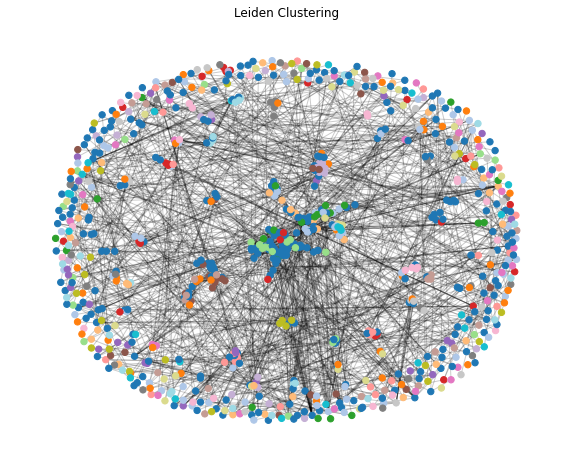

In [57]:
import networkx as nx
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg


def get_leiden_clusters(G, resolution=0.2):
    ig_g = ig.Graph.TupleList(G.edges(), directed=True)
    ig_g.vs["name"] = list(G.nodes())
    weights = [G[u][v].get("weight", 0.0) for u, v in G.edges()]

    partition = leidenalg.find_partition(
        ig_g,
        leidenalg.RBConfigurationVertexPartition,
        weights=weights,
        resolution_parameter=resolution,
    )

    clusters = [[ig_g.vs[idx]["name"] for idx in cluster] for cluster in partition]
    print(f"Leiden found {len(clusters)} clusters.")

    node_to_cluster = {}
    for i, cluster in enumerate(clusters):
        for node in cluster:
            node_to_cluster[node] = i
    
    return node_to_cluster


node_to_cluster = get_leiden_clusters(G)
clustered_nodes = set(node_to_cluster.keys())
G_clustered = G.subgraph(clustered_nodes).copy()

# Visualize only clustered part
pos = nx.spring_layout(G_clustered, seed=42)
fig = plt.figure(figsize=(10, 8))
colors = [node_to_cluster[node] for node in G_clustered.nodes()]
nx.draw_networkx_nodes(G_clustered, pos, node_color=colors, cmap=plt.cm.tab20, node_size=40)
nx.draw_networkx_edges(G_clustered, pos, alpha=0.2)
fig.set_facecolor('white')
plt.axis("off")
plt.title("Leiden Clustering")
plt.show()

MCL found 607 clusters.


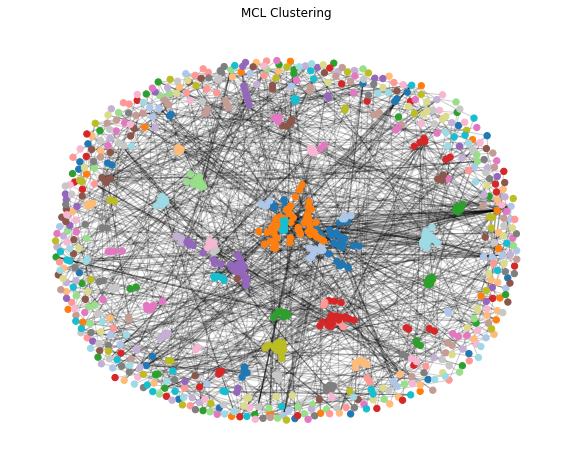

In [58]:
import markov_clustering as mc
import scipy.sparse as sp
import numpy as np

def get_mcl_clusters(G):
    node_list = list(G.nodes())
    node_index = {node: i for i, node in enumerate(node_list)}

    # Create adjacency matrix
    row, col, data = [], [], []
    for u, v, attrs in G.edges(data=True):
        i, j = node_index[u], node_index[v]
        weight = attrs.get("weight", 0.0)
        row.append(i)
        col.append(j)
        data.append(weight)

    matrix = sp.coo_matrix((data, (row, col)), shape=(len(node_list), len(node_list)))

    # Run MCL with tuning
    result = mc.run_mcl(matrix)  
    clusters = mc.get_clusters(result)
    print(f"MCL found {len(clusters)} clusters.")

    # Map cluster IDs for visualization
    mcl_node_to_cluster = {}
    for cluster_id, cluster in enumerate(clusters):
        for idx in cluster:
            mcl_node_to_cluster[node_list[idx]] = cluster_id
    
    return mcl_node_to_cluster

node_to_cluster = get_mcl_clusters(G)
pos = nx.spring_layout(G)
fig = plt.figure(figsize=(10, 8))
colors = [node_to_cluster[node] for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.tab20, node_size=40)
nx.draw_networkx_edges(G, pos, alpha=0.2)
fig.set_facecolor('white')
plt.axis("off")
plt.title("MCL Clustering")
plt.show()

Filtering out clusters smaller than some threshold

In [65]:
from pyvis.network import Network
from collections import defaultdict
import networkx as nx

# Compute Leiden clusters
node_to_cluster = get_leiden_clusters(G)

# Group nodes by cluster
cluster_to_nodes = defaultdict(list)
for node, cluster_id in node_to_cluster.items():
    cluster_to_nodes[cluster_id].append(node)

# Only keep large clusters
min_size = 5
large_clusters = {
    cid: nodes for cid, nodes in cluster_to_nodes.items() if len(nodes) >= min_size
}

# Remap node to cluster for large clusters only
filtered_node_to_cluster = {
    node: cid for cid, nodes in large_clusters.items() for node in nodes
}

# Map each cluster to a unique color
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cluster_ids = list(large_clusters.keys())
color_map = cm.get_cmap('tab20', len(cluster_ids))
cluster_colors = {
    cid: mcolors.to_hex(color_map(i)) for i, cid in enumerate(cluster_ids)
}

# Create Pyvis network
net = Network(height='700px', width='100%', bgcolor='white', font_color='black', notebook=True)
net.force_atlas_2based()

# Add nodes
for node in G.nodes():
    if node in filtered_node_to_cluster:
        cluster_id = filtered_node_to_cluster[node]
        color = cluster_colors[cluster_id]
        title = f'Node: {node}<br>Cluster: {cluster_id}'
    else:
        color = '#D3D3D3'  # gray
        title = f'Node: {node}<br>Unclustered'
    
    net.add_node(node, label=str(node), title=title, color=color)

# Add edges
for source, target in G.edges():
    net.add_edge(source, target)

# Show the graph
net.show('leiden_communities.html')


Leiden found 500 clusters.
leiden_communities.html


<ipython-input-65-193dd64a0448>:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

